# Tecnicas de agrupamiento y deteccion de anomalias
Como ultima actividad de la materia de aprendizaje automatico, haremos el analisis, agrupamiento y deteccion de anomalias para hacer la prediccion de nuestra variable de salida NSP.

In [124]:
# importamos las librerias
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances_argmin_min

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cargamos el dataset

In [125]:
data = pd.read_csv('/content/drive/MyDrive/archivos CSV/CTG.csv')

# Descripcion de las columnas de dataset

* *FileName*: of CTG examination

* *Date*: of the examination

* *b*: start instant

* *e*: end instant

* *LBE*: baseline value (medical expert)

* *LB*: baseline value (SisPorto)

* *AC*: accelerations (SisPorto)

* *FM*: foetal movement (SisPorto)

* *UC*: uterine contractions (SisPorto)

* *ASTV*: percentage of time with abnormal short term variability (SisPorto)

* *mSTV*: mean value of short term variability (SisPorto)

* *ALTV*: percentage of time with abnormal long term variability (SisPorto)

* *mLTV*: mean value of long term variability (SisPorto)

* *DL*: light decelerations

* *DS*: severe decelerations

* *DP*: prolongued decelerations

* *DR*: repetitive decelerations

* *Width*: histogram width

* *Min*: low freq. of the histogram

* *Max*: high freq. of the histogram

* *Nmax*: number of histogram peaks

* *Nzeros*: number of histogram zeros

* *Mode*: histogram mode

* *Mean*: histogram mean

* *Median*: histogram median

* *Variance*: histogram variance

* *Tendency*: histogram tendency: -1=left assymetric; 0=symmetric; 1=right assymetric

* *A*: calm sleep

* *B*: REM sleep

* *C*: calm vigilance

* *D*: active vigilance

* *SH*: shift pattern (A or Susp with shifts)

* *AD*: accelerative/decelerative pattern (stress situation)

* *DE*: decelerative pattern (vagal stimulation)

* *LD*: largely decelerative pattern

* *FS*: flat-sinusoidal pattern (pathological state)

* *SUSP*: suspect pattern

* *CLASS*: Class code (1 to 10) for classes A to SUSP

* *NSP*: Normal=1; Suspect=2; Pathologic=3

# 1. ANÁLISIS DESCRIPTIVO DE DATOS


## Variables numéricas

In [126]:
#Información de las variables
data.info()
#Resumen estadístico de las variables
data.describe()

data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2126 non-null   object 
 1   Date      2126 non-null   object 
 2   SegFile   2126 non-null   object 
 3   b         2126 non-null   float64
 4   e         2126 non-null   float64
 5   LBE       2126 non-null   float64
 6   LB        2126 non-null   float64
 7   AC        2126 non-null   float64
 8   FM        2127 non-null   float64
 9   UC        2127 non-null   float64
 10  ASTV      2127 non-null   float64
 11  MSTV      2127 non-null   float64
 12  ALTV      2127 non-null   float64
 13  MLTV      2127 non-null   float64
 14  DL        2128 non-null   float64
 15  DS        2128 non-null   float64
 16  DP        2128 non-null   float64
 17  DR        2128 non-null   float64
 18  Width     2126 non-null   float64
 19  Min       2126 non-null   float64
 20  Max       2126 non-null   floa

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
5,Fmcs_2.txt,5/3/1996,CTG0006.txt,0.0,953.0,134.0,134.0,1.0,0.0,10.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
6,Fmcs_2.txt,5/3/1996,CTG0007.txt,240.0,953.0,134.0,134.0,1.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
7,Hasc_1.txt,2/22/1995,CTG0008.txt,62.0,679.0,122.0,122.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0
8,Hasc_1.txt,2/22/1995,CTG0009.txt,120.0,779.0,122.0,122.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0
9,Hasc_1.txt,2/22/1995,CTG0010.txt,181.0,1192.0,122.0,122.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0


# Detectando valores nulos

In [127]:
# data.isna().sum()
data.isnull().sum()

,0
FileName,3
Date,3
SegFile,3
b,3
e,3
LBE,3
LB,3
AC,3
FM,2
UC,2


# Eliminando los nulos
Dado que en todas las columnas el numero maximo de registros nulos es 3, esto nos permite poder elminiar las filas que tengan registros nulos sin afectar de forma significativa el resultado de nuestro analisis, podemos incluso decir que dado que los registros nulos son tan pocos el hecho de eliminarlo no va a afectar el resultado. Pocedemos a eliminar esas filas.

In [128]:
# eliminar los registros nulos
data = data.dropna()
data.isnull().sum()

,0
FileName,0
Date,0
SegFile,0
b,0
e,0
LBE,0
LB,0
AC,0
FM,0
UC,0


# Eliminando columnas
Como podemos ver en la descripcion del dataset, hay columnas referentes al nombre del archivo donde se guardo la informacion o la fecha de toma del estudio. Estos datos no nos sirven para nuestro estudio por lo que podemos eliminar las columnas FileName, Date, SegFile, b y e.

In [129]:
data = data.drop(["FileName", "Date", "SegFile", "b", "e", "CLASS"], axis = 1)
data.describe()
data.head(10)

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,B,C,D,E,AD,DE,LD,FS,SUSP,NSP
0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
1,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,134.0,134.0,1.0,0.0,10.0,26.0,5.9,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
6,134.0,134.0,1.0,0.0,9.0,29.0,6.3,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
7,122.0,122.0,0.0,0.0,0.0,83.0,0.5,6.0,15.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
8,122.0,122.0,0.0,0.0,1.0,84.0,0.5,5.0,13.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
9,122.0,122.0,0.0,0.0,3.0,86.0,0.3,6.0,10.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0


# Matriz de correlacion

[Text(0.5, 0, 'LBE'),
 Text(1.5, 0, 'LB'),
 Text(2.5, 0, 'AC'),
 Text(3.5, 0, 'FM'),
 Text(4.5, 0, 'UC'),
 Text(5.5, 0, 'ASTV'),
 Text(6.5, 0, 'MSTV'),
 Text(7.5, 0, 'ALTV'),
 Text(8.5, 0, 'MLTV'),
 Text(9.5, 0, 'DL'),
 Text(10.5, 0, 'DS'),
 Text(11.5, 0, 'DP'),
 Text(12.5, 0, 'DR'),
 Text(13.5, 0, 'Width'),
 Text(14.5, 0, 'Min'),
 Text(15.5, 0, 'Max'),
 Text(16.5, 0, 'Nmax'),
 Text(17.5, 0, 'Nzeros'),
 Text(18.5, 0, 'Mode'),
 Text(19.5, 0, 'Mean'),
 Text(20.5, 0, 'Median'),
 Text(21.5, 0, 'Variance'),
 Text(22.5, 0, 'Tendency'),
 Text(23.5, 0, 'A'),
 Text(24.5, 0, 'B'),
 Text(25.5, 0, 'C'),
 Text(26.5, 0, 'D'),
 Text(27.5, 0, 'E'),
 Text(28.5, 0, 'AD'),
 Text(29.5, 0, 'DE'),
 Text(30.5, 0, 'LD'),
 Text(31.5, 0, 'FS'),
 Text(32.5, 0, 'SUSP'),
 Text(33.5, 0, 'NSP')]

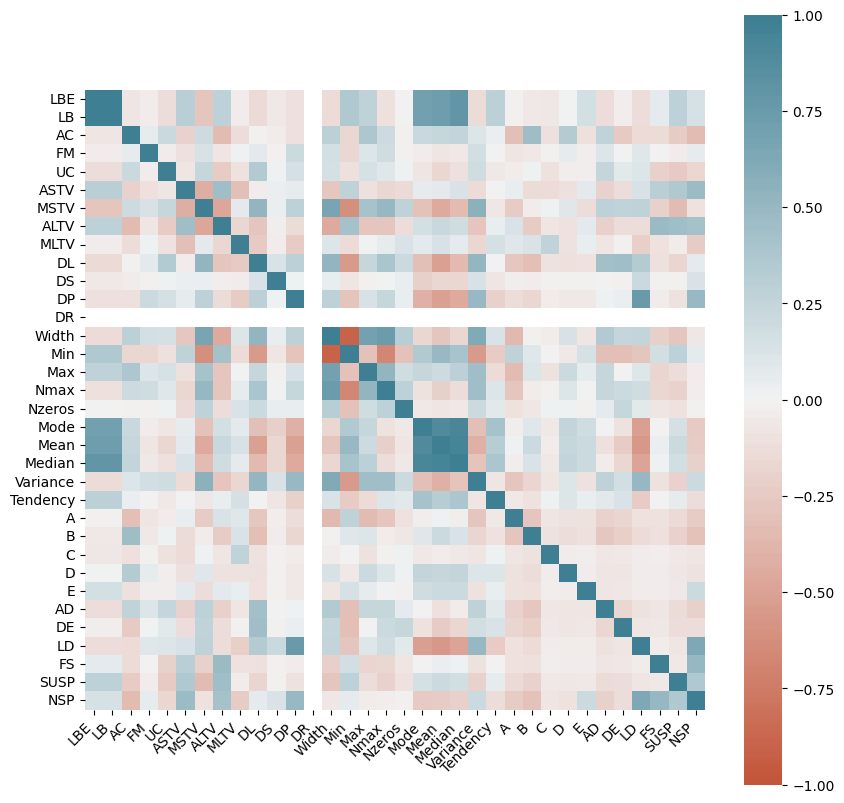

In [130]:
corr = data.corr()
ax = sns.heatmap(
    corr,
    vmin = -1, vmax = 1, center = 0,
    cmap=sns.diverging_palette(20, 220, n = 200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment = 'right'
)

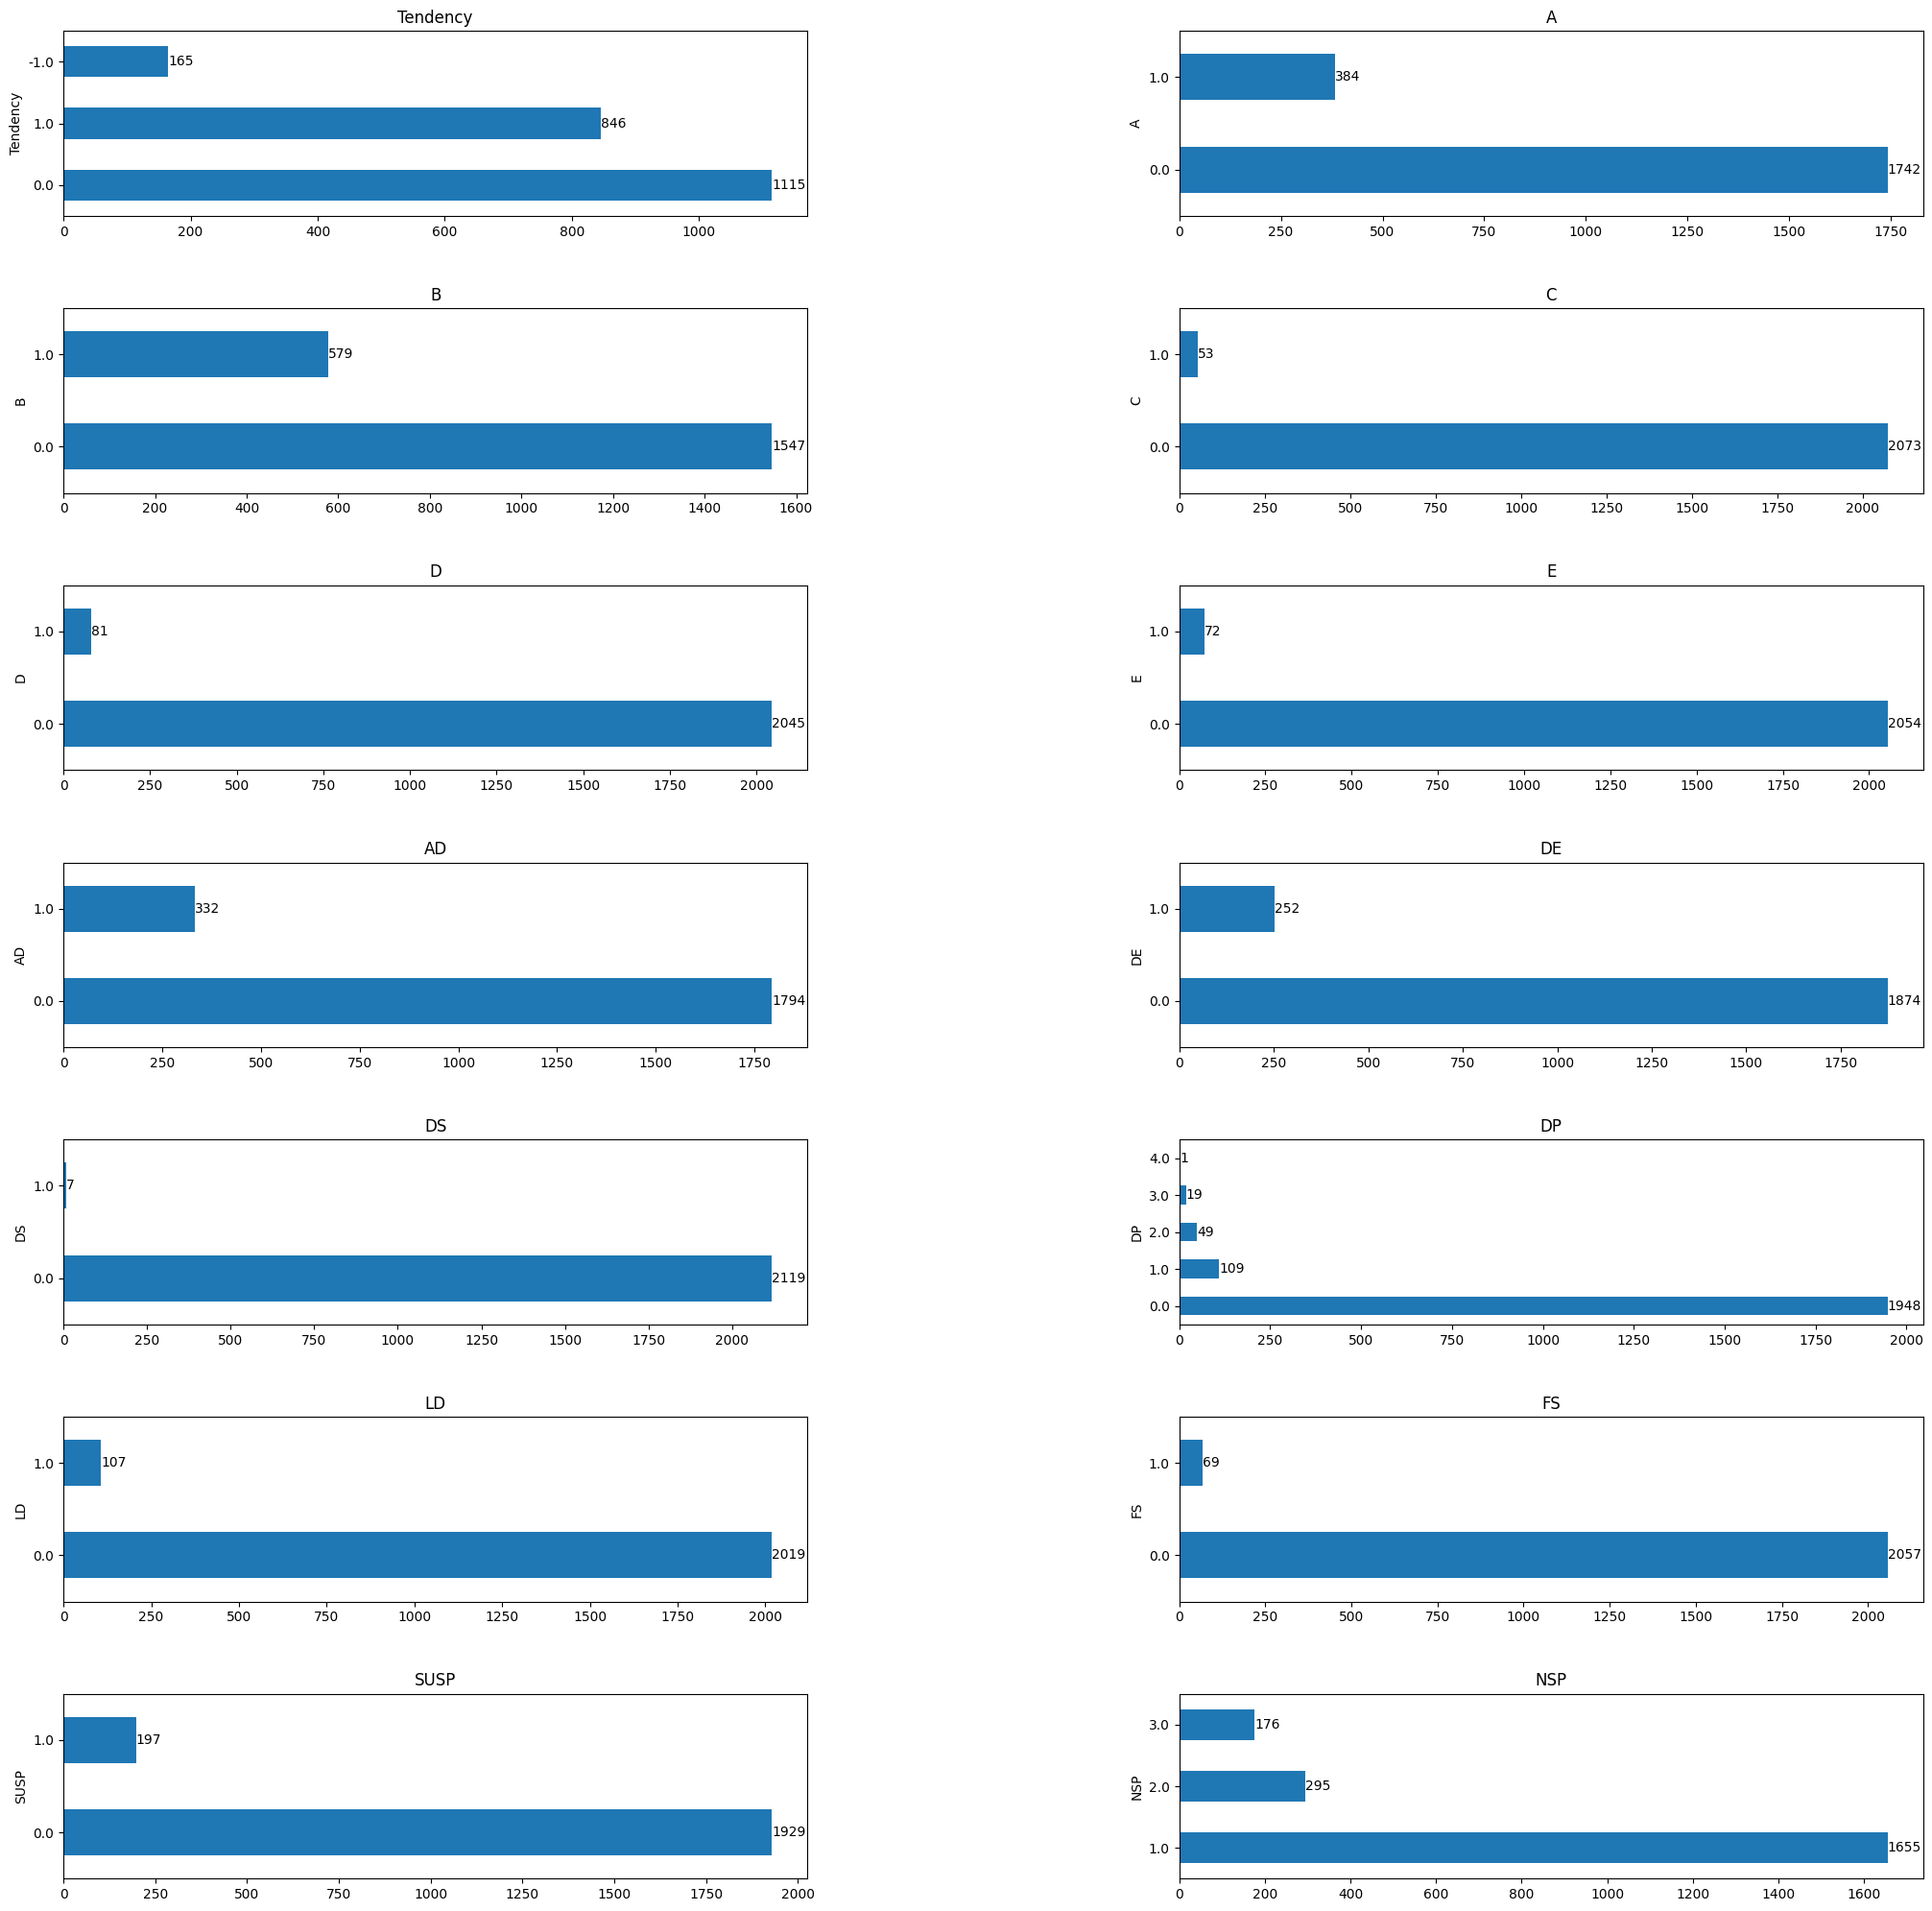

In [131]:
data.NSP.value_counts()
# el dataset no esta nada balanceado
lista_categoricas = ['Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE','DS', 'DP', 'LD', 'FS', 'SUSP', 'NSP']

fig, axes = plt.subplots(nrows = 7, ncols = 2, figsize = (25, 25))

plt.subplots_adjust(
    wspace = 0.5,
    hspace = 0.5
)

for col, ax in zip(data[lista_categoricas], axes.ravel()):
  data[col].value_counts().plot.barh(ax = ax)
  ax.set_title(col)
  ax.bar_label(ax.containers[0])

plt.show()



In [132]:
# creamos una copia del dataset y verificamos su tamaño
copy_data = data.copy()
copy_data.shape

if copy_data.shape == data.shape:
  print('Son iguales')
else:
  print('No son iguales')

# creamos las variables categoricas con get_dummies
for col in lista_categoricas[:-1]:
  copy_data_temp = pd.get_dummies(data[col], prefix = col, drop_first = True)
  copy_data = pd.concat([copy_data, copy_data_temp], axis = 1)
  copy_data.drop(col, axis = 1, inplace = True)

copy_data.shape
copy_data.info()



Son iguales
<class 'pandas.core.frame.DataFrame'>
Index: 2126 entries, 0 to 2125
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LBE           2126 non-null   float64
 1   LB            2126 non-null   float64
 2   AC            2126 non-null   float64
 3   FM            2126 non-null   float64
 4   UC            2126 non-null   float64
 5   ASTV          2126 non-null   float64
 6   MSTV          2126 non-null   float64
 7   ALTV          2126 non-null   float64
 8   MLTV          2126 non-null   float64
 9   DL            2126 non-null   float64
 10  DR            2126 non-null   float64
 11  Width         2126 non-null   float64
 12  Min           2126 non-null   float64
 13  Max           2126 non-null   float64
 14  Nmax          2126 non-null   float64
 15  Nzeros        2126 non-null   float64
 16  Mode          2126 non-null   float64
 17  Mean          2126 non-null   float64
 18  Median        2126 no

# Diagrama de caja y bigote

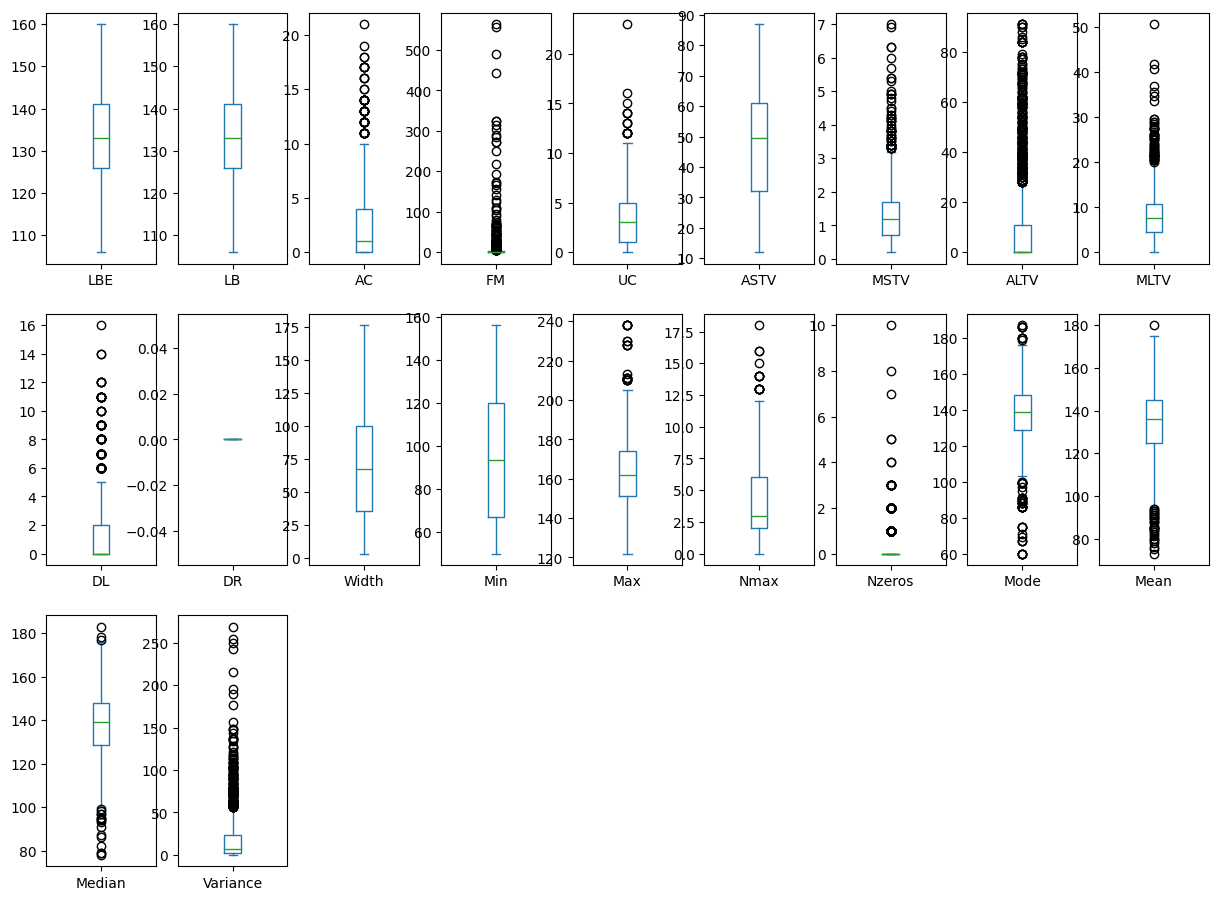

In [133]:
X = copy_data.drop('NSP', axis=1)
y = copy_data['NSP']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

X_train.plot(kind='box', subplots=True, layout=(4, 9),
             sharex=False, sharey=False, figsize=(15, 15))
plt.show()

# Outliers con Isolation forest

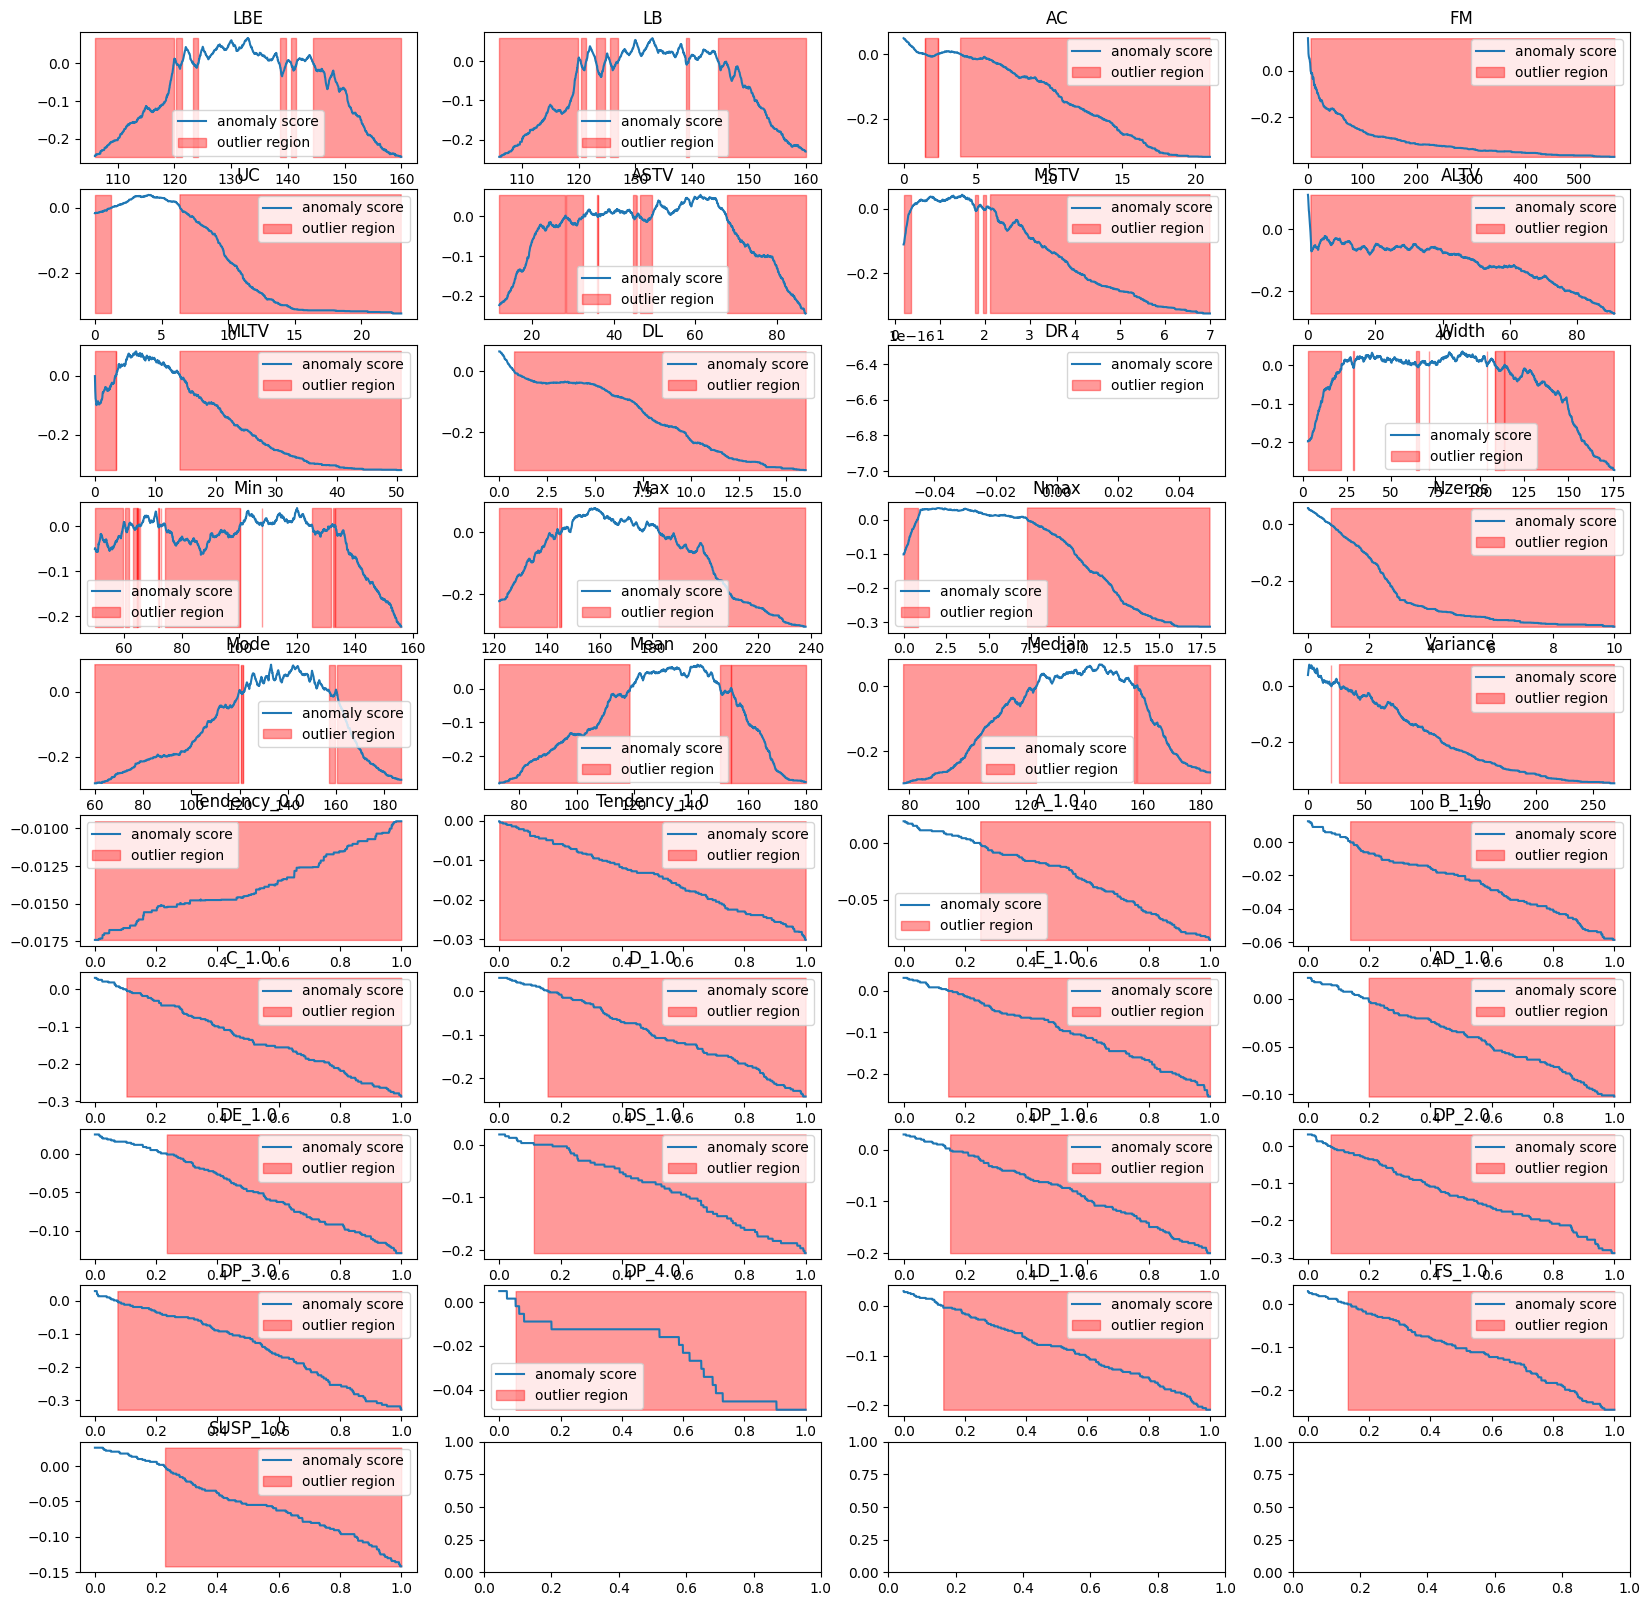

In [134]:
lista_columnas = X_train.columns
fig, axs = plt.subplots(nrows = 10, ncols = 4, figsize=(20, 20), facecolor='w', edgecolor='k')
axs = axs.ravel()

for i, column in enumerate(lista_columnas):
    isolation_forest = IsolationForest(contamination='auto')
    isolation_forest.fit(X_train[column].values.reshape(-1,1))

    xx = np.linspace(X_train[column].min(), X_train[column].max(), len(X_train)).reshape(-1, 1)
    anomaly_score = isolation_forest.decision_function(xx)
    outlier = isolation_forest.predict(xx)

    axs[i].plot(xx, anomaly_score, label='anomaly score')
    axs[i].fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score),
                     where=outlier==-1, color='r',
                     alpha=.4, label='outlier region')
    axs[i].legend()
    axs[i].set_title(column)


# Outliers con K-Means

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

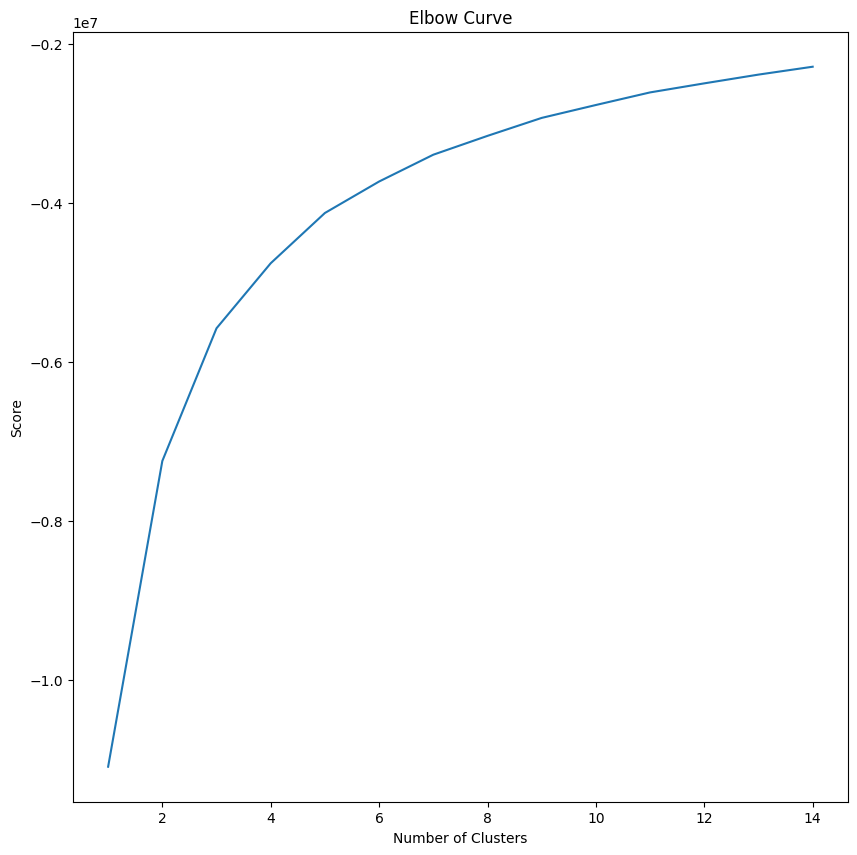

In [135]:
X_np_Train = X_train.to_numpy()

Nc = range(1, 15)
kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(X_np_Train).score(X_np_Train) for i in range(len(kmeans))]

plt.rcParams['figure.figsize'] = (10, 10)
plt.plot(Nc, score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[0 0 1 ... 1 0 1]


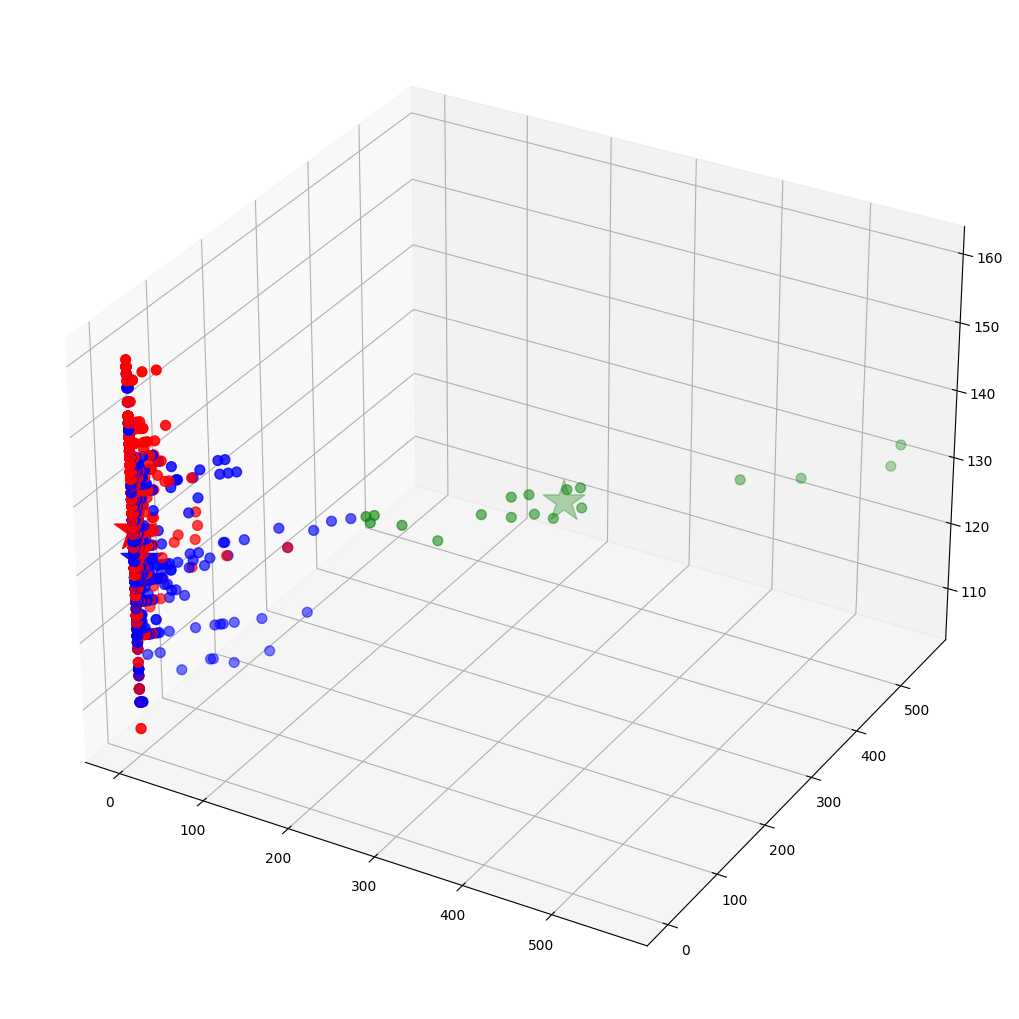

In [136]:
# los mejores valores de clusters son 4 y 5

kmeans = KMeans(n_clusters = 3).fit(X_np_Train)
centroids = kmeans.cluster_centers_

#Graficamos en 3D para ver si es coherente
labels = kmeans.predict(X_np_Train)
print(labels)
# Getting the cluster centers
C = kmeans.cluster_centers_
colores=['red', 'blue', 'green']
asignar=[]
for row in labels:
    asignar.append(colores[row])
fig = plt.figure(figsize=(10, 10))
ax = Axes3D(fig, auto_add_to_figure = False)
fig.add_axes(ax)
ax.scatter(X_np_Train[:, 3], X_np_Train[:, 3], X_np_Train[:, 0], c = asignar, s = 50) # Datos
ax.scatter(C[:, 3], C[:, 3], C[:, 0], marker='*', c=colores, s=1000); # Centroides

# Anomalias
Quise hacer la comparacion del algoritmo de K-Means con IsolationForest y podemos ver en ambas graficas que que hay datos muy dispersos en todas las categorias y variables numericas, de hecho esto lo podemos ver mas claro en las graficas hechas con IsolationForest, en el que las regiones outliers abarcan en la mayoria de las graficas de 2/3 a 3/4 de la grafica.
Esto mismo podemos corroborarlo con la grafica de los clusters, en la que vemos que los puntos de todos los clusters estan muy disersos entre si.
Teniendo esto en cuenta y como en una celda anterior lo habiamos visto, este dataset esta muy desbalanceado y tiene muchas anomalias.

# Agrupando con K-Means

In [137]:
# estandarizando los datos
scaler_train = MinMaxScaler()
X_train = scaler_train.fit_transform(X_train)

scaler_test = MinMaxScaler()
X_test = scaler_test.fit_transform(X_test)

# agrupando con k-means, usaremos el 3 que en la deteccion de anomalias
means = KMeans(n_clusters = 4)
means.fit(X_train, y_train)

print(f'Centroides:\n{means.cluster_centers_}')
print(f'Etiquetas: {means.labels_}')
predictKmeans = means.predict(X_test)

print(accuracy_score(y_test, predictKmeans))
print(classification_report(y_test, predictKmeans))

Centroides:
[[ 5.27964834e-01  5.27964834e-01  2.27272727e-02  3.52371230e-03
   1.20443566e-01  5.55824916e-01  8.06224005e-02  2.43256743e-01
   1.60241468e-01  4.41919192e-03  0.00000000e+00  1.64462545e-01
   6.83438155e-01  2.74969523e-01  1.02132435e-01  1.13636364e-02
   6.15008351e-01  6.02567733e-01  5.82034632e-01  7.03127934e-03
   8.76262626e-01 -1.05471187e-15  5.47979798e-01  1.83186799e-15
   3.78787879e-02  2.27272727e-02  7.07070707e-02  8.88178420e-16
   7.21644966e-16  8.67361738e-18  2.52525253e-03  0.00000000e+00
   4.51028104e-17  1.95156391e-18  3.40005801e-16  8.83838384e-02
   2.32323232e-01]
 [ 4.67344316e-01  4.67344316e-01  2.54619198e-01  6.67830056e-03
   1.67192429e-01  4.04752892e-01  1.58378178e-01  3.09910909e-02
   1.67279538e-01  1.65615142e-02  0.00000000e+00  3.44906183e-01
   5.26813880e-01  4.00957250e-01  1.96985629e-01  1.70347003e-02
   6.14421620e-01  6.10336390e-01  5.86510440e-01  3.74913513e-02
   8.86435331e-01  9.99200722e-16 -1.38777878

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-sc

# Haciendo predicciones con un clasificador SVM y ML

In [138]:
# probando con modelos SVG y redes neuronales
# Parametros y los valores que van a tomar
param_grid = {'C': np.linspace(0.1, 100, 100),
              'kernel': ['linear', 'rbf']
              }

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)



Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.988 total time=   0.0s
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.988 total time=   0.0s
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.976 total time=   0.0s
[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.982 total time=   0.0s
[CV 5/5] END ..............C=0.1, kernel=linear;, score=0.979 total time=   0.0s
[CV 1/5] END .................C=0.1, kernel=rbf;, score=0.988 total time=   0.0s
[CV 2/5] END .................C=0.1, kernel=rbf;, score=0.988 total time=   0.0s
[CV 3/5] END .................C=0.1, kernel=rbf;, score=0.976 total time=   0.0s
[CV 4/5] END .................C=0.1, kernel=rbf;, score=0.982 total time=   0.0s
[CV 5/5] END .................C=0.1, kernel=rbf;, score=0.979 total time=   0.0s
[CV 1/5] END C=1.1090909090909091, kernel=linear;, score=0.988 total time=   0.0s
[CV 2/5] END C=1.1090909090909091, kernel=li

GridSearchCV(estimator=SVC(),
             param_grid={'C': array([  0.1       ,   1.10909091,   2.11818182,   3.12727273,
         4.13636364,   5.14545455,   6.15454545,   7.16363636,
         8.17272727,   9.18181818,  10.19090909,  11.2       ,
        12.20909091,  13.21818182,  14.22727273,  15.23636364,
        16.24545455,  17.25454545,  18.26363636,  19.27272727,
        20.28181818,  21.29090909,  22.3       ,  23.30909091,
        24.31818182,  25.32727273,  26.33636364,  27.34...
        72.75454545,  73.76363636,  74.77272727,  75.78181818,
        76.79090909,  77.8       ,  78.80909091,  79.81818182,
        80.82727273,  81.83636364,  82.84545455,  83.85454545,
        84.86363636,  85.87272727,  86.88181818,  87.89090909,
        88.9       ,  89.90909091,  90.91818182,  91.92727273,
        92.93636364,  93.94545455,  94.95454545,  95.96363636,
        96.97272727,  97.98181818,  98.99090909, 100.        ]),
                         'kernel': ['linear', 'rbf']},
             verbose=3)

In [139]:
# trabajando con el mejor model del grid
print(grid.best_estimator_)
best_grid = grid.best_estimator_
predict_best_grid = best_grid.predict(X_test)

# exactitud del modelo
print(accuracy_score(y_test, predict_best_grid))
print(classification_report(y_test, predict_best_grid))


SVC(C=28.354545454545455)
0.9882629107981221
              precision    recall  f1-score   support

         1.0       1.00      0.99      0.99       336
         2.0       0.93      0.98      0.96        55
         3.0       1.00      1.00      1.00        35

    accuracy                           0.99       426
   macro avg       0.98      0.99      0.98       426
weighted avg       0.99      0.99      0.99       426



In [140]:
# Clasificador de red neuronal
mlp_classifier = MLPClassifier(hidden_layer_sizes=(300, 200), activation='logistic', solver='lbfgs', alpha=1e-5, random_state=1)
mlp_classifier.fit(X_train, y_train)

# Predicción del modelo
predict_mlp = mlp_classifier.predict(X_test)
print(accuracy_score(y_test, predict_mlp))
print(classification_report(y_test, predict_mlp))

0.9788732394366197
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       336
         2.0       0.93      0.91      0.92        55
         3.0       0.92      1.00      0.96        35

    accuracy                           0.98       426
   macro avg       0.95      0.97      0.96       426
weighted avg       0.98      0.98      0.98       426



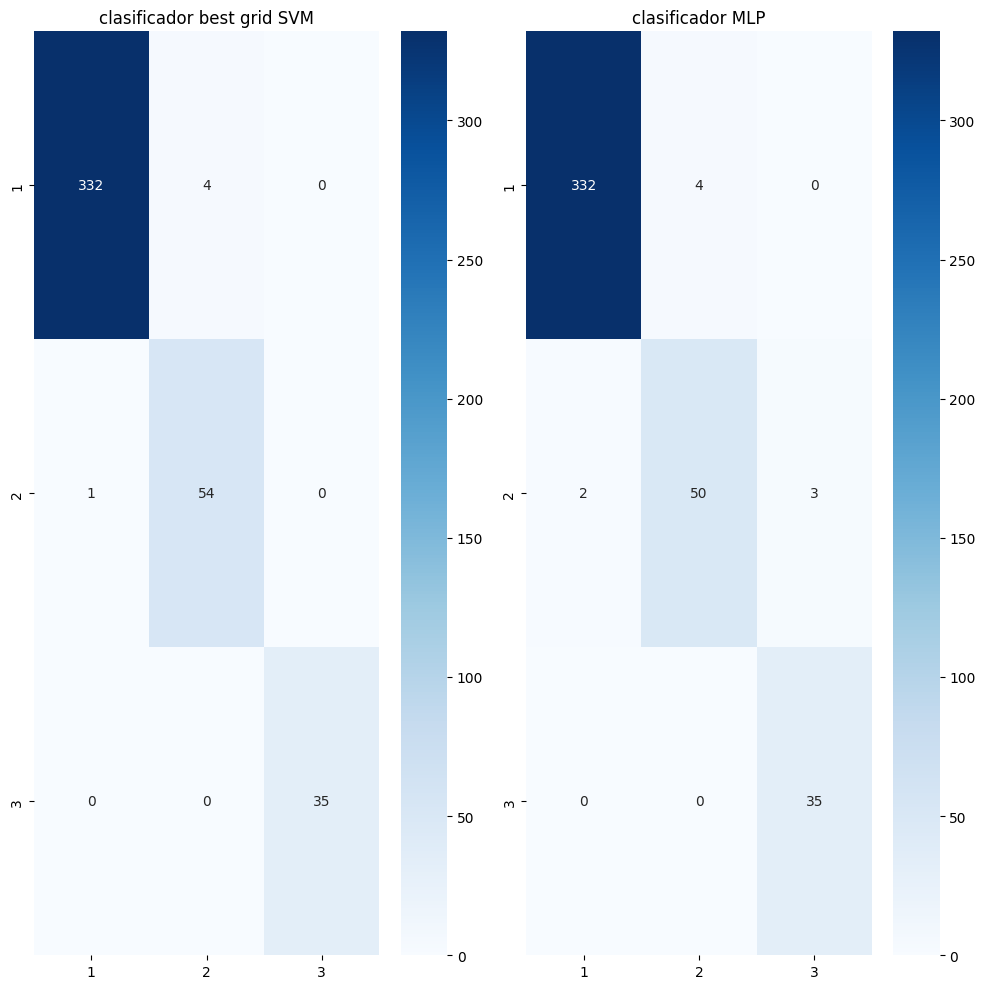

In [141]:
matris_confusion_Kmeans = confusion_matrix(y_test, predictKmeans)
matris_confusion_svm_best_grid = confusion_matrix(y_test, predict_best_grid)
matris_confusion_mlp = confusion_matrix(y_test, predict_mlp)

mat_inf = [
    #{'type': 'clasificador por K-Means', 'conf_mat': matris_confusion_Kmeans},
    {'type': 'clasificador best grid SVM', 'conf_mat': matris_confusion_svm_best_grid},
    {'type': 'clasificador MLP', 'conf_mat': matris_confusion_mlp}
]

class_label = ["1", "2", "3"]
n_alg = len(mat_inf)

fig, ax = plt.subplots(1, len(mat_inf))

for i, inf_alg in enumerate(mat_inf):
    c = sns.heatmap(inf_alg['conf_mat'], annot = True, fmt = 'g', cmap=plt.cm.Blues, ax = ax[i])
    c.set(xticklabels = class_label, yticklabels = class_label)
    ax[i].set_title(inf_alg['type'])
plt.tight_layout()
plt.show()

# Conclusiones
Esta actividad si fue mas retadora, ya que no tenia una guia de instrucciones mas explisitas como en la actividad anterior de esta materia, tuve que avanzar poco a poco leyendo codigo y viendo ejemplos de lo que se pedia pero es tambien en base a esto que puedo sacar las siguientes conclusiones:
* 1.- El agrupamiento por clusters si que no es una buena manera de hacer inferencias. Esto lo podemos corroborar porque el acurracy de este metodo fue de solo el 35% y si lo comparamos con los otros dos metodos que usamos el agrupamiento por clusters palidece mucho en rendimiento. Esto se me hacia increible al momento de ver los contenidos grabados pero lo he comprobado con este ejercicio. Ademas de esto, el algoritmo K-Means me genero una categoria extra en la que no hay nada y por eso no aparece el el grafico comparativo de las matrices de confusion.

* 2.- Pude mejorar mucho la red neuronal de la actividad anterior. En la actividad anterior hicimos un clasificados con una SVM y una red neuronal y decidi volver a usar estos clasificadores para comparar el accuracy de los clusters y obtuve muy buenos resultados con ambos algoritmos, mejorando el accuracy de la SVM y la MLC del 95% y del 92% al 99% y 98% respectivamente para cada modelo. Esto lo logre jugando con los parametros de ambas instancias hasta que logre un buen ajuste y la verdad que la mejora fue muy buena para ambos modelos.

* 3.- La deteccion de anomalias fue retadora. Esta fue la parte en la que mas batalle pero me ayudo mucho a dislumbrar las caracteristicas del dataset, ya habia visto que no estaba bien balanceado pero obteniendo las anomalias lo vi mas claro. Esto tambien me permitio aprender un poco mas a como hacer este proceso y a entender los resultados

Puedo decir que esta fue de las materias que mas disfrute hasta ahora y me quedo satisfecho con lo aprendido hasta ahora. Estas cosas en teoria las debi de haber aprendido en la universidad pero me siento contento de poderlas aprender ahora y estar en el proceso de entenderlas y de saber como aplicarlos a los problemas.